In [1]:
import experiment_utils
from experiment_utils import config

config.experiment_name = "inHomo_realHelmholtz_dirichlet_3d"
config.target = "jmlr_docker"
config.debug_mode = True

In [2]:
import numpy as np
import probnum as pn
import linpde_gp

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.gridspec as gridspec

In [4]:
%matplotlib inline

In [5]:
plt.rcParams.update(config.tueplots_bundle())
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica'],
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
plt.rcParams['text.usetex'] = True

In [6]:
rng = np.random.default_rng(24)

## Problem Definition

In [7]:
rho, omega, Gp, Gpp = 1.0, 1.0, 1.0, 0.0

In [8]:
bvp = linpde_gp.problems.pde.HelmholtzEquationDirichletProblem(
    domain=linpde_gp.domains.Box([[-1.0, 1.0], [-1.0, 1.0], [-1.0, 1.0]]),
    rho=rho,
    omega=omega,
    G_real=Gp,
    G_imag=Gpp,
    rhs=linpde_gp.functions.Constant(input_shape=(3,), value=2.0),
    boundary_values=linpde_gp.functions.Constant(input_shape=(3,), value=0.0),
)

In [9]:
print(f"Wave number k²: {bvp.pde.k_squared:.4f}")
print(f"Wave number k: {np.sqrt(bvp.pde.k_squared):.4f}")
print(f"Wavelength λ = 2π/k: {2*np.pi/np.sqrt(bvp.pde.k_squared):.4f}")

Wave number k²: 1.0000
Wave number k: 1.0000
Wavelength λ = 2π/k: 6.2832


## GP Prior

In [10]:
prior_gp = pn.randprocs.GaussianProcess(
    mean=linpde_gp.functions.Zero(input_shape=(3,)),
    cov=2.0 ** 2 * linpde_gp.randprocs.covfuncs.TensorProduct(
        linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
        linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
        linpde_gp.randprocs.covfuncs.ExpQuad((), lengthscales=1.0),
    ),
)

## Boundary Conditions

In [11]:
def _normalize_xy(X, Y, d=3):
    X = np.asarray(X)
    Y = np.asarray(Y)
    if X.ndim == 3 and X.shape[0] == 1 and X.shape[-1] == d:
        X = X[0]                  # (N, d)
    if Y.ndim == 2 and Y.shape[0] == 1 and Y.shape[1] == X.shape[0]:
        Y = Y[0]                  # (N,)
    X = X.reshape(-1, d)
    Y = Y.reshape(-1)
    return X, Y

N_bc_face = 12
u_bc = prior_gp

X_bc_list = []
Y_bc_list = []

for i, boundary_condition in enumerate(bvp.boundary_conditions):
    X_bc = boundary_condition.boundary.uniform_grid((N_bc_face, N_bc_face), inset=1e-4)
    Y_bc = boundary_condition.values(X_bc)
    X_bc, Y_bc = _normalize_xy(X_bc, Y_bc, d=3)

    X_bc_list.append(X_bc)
    Y_bc_list.append(Y_bc)

    assert X_bc.shape == (N_bc_face ** 2, 3)
    assert Y_bc.shape == (N_bc_face ** 2,)
    print(f"  Face {i+1}: {X_bc.shape[0]} points")

    jitter = 1e-6
    noise = pn.randvars.Normal(
        mean=np.zeros(Y_bc.shape),
        cov=jitter * np.eye(Y_bc.shape[0])
    )
    u_bc = u_bc.condition_on_observations(Y=Y_bc, X=X_bc, b=noise)

  Face 1: 144 points
  Face 2: 144 points
  Face 3: 144 points
  Face 4: 144 points
  Face 5: 144 points
  Face 6: 144 points


### Conditioning on the PDE

In [12]:
N_pde = 11

print(f"\nConditioning on PDE with {N_pde}³ = {N_pde**3} interior points...")
X_pde = bvp.domain.uniform_grid((N_pde, N_pde, N_pde), inset=1e-6)
Y_pde = bvp.pde.rhs(X_pde)

X_pde_flat, Y_pde_flat = _normalize_xy(X_pde, Y_pde, d=3)
jitter = 1e-6
noise_pde = pn.randvars.Normal(
    mean=np.zeros(Y_pde_flat.shape),
    cov=jitter * np.eye(Y_pde_flat.size)
)
u_bc_pde = u_bc.condition_on_observations(
    Y=Y_pde_flat,
    L=bvp.pde.diffop,
    X=X_pde_flat,
    b=noise_pde
)


Conditioning on PDE with 11³ = 1331 interior points...


In [13]:
print(Y_pde.shape)

(11, 11, 11)


In [14]:
def _points_near_slice(pts, z_val, atol):
    """Return (N, 3) subset of `pts` whose third coordinate is within `atol` of `z_val`."""
    pts = np.asarray(pts).reshape(-1, 3)
    mask = np.abs(pts[:, 2] - z_val) < atol
    return pts[mask]


def plot_multiplane_slices(
    u_post,
    bvp,
    z_slices=(-0.50, 0.0, 0.50),
    resolution=50,
    X_pde=None,
    X_bc_list=None,
    extent=(-1, 1, -1, 1),
    figsize=(5.5, 3.6),
    slice_tol=None,
    show_domain_outline=True,
):
    from matplotlib import patches
    n_slices = len(z_slices)

    # 1. Evaluate posterior mean and std on every slice
    x = np.linspace(extent[0], extent[1], resolution)
    y = np.linspace(extent[2], extent[3], resolution)
    xx, yy = np.meshgrid(x, y, indexing='ij')

    means, cis = [], []
    for z_val in z_slices:
        grid = np.stack([xx, yy, np.full_like(xx, z_val)], axis=-1)
        X_flat = grid.reshape(-1, 3)

        u_mean = np.asarray(u_post.mean(grid))
        if u_mean.shape != (resolution, resolution):
            u_mean = u_mean.reshape(resolution, resolution)

        with np.errstate(invalid='ignore'):
            u_std = np.asarray(u_post.std(X_flat)).reshape(resolution, resolution)
        u_std = np.maximum(np.nan_to_num(u_std, nan=0.0), 0.0)

        means.append(u_mean)
        cis.append(1.96 * u_std)

    vmin_mean = min(m.min() for m in means)
    vmax_mean = max(m.max() for m in means)
    vmax_ci   = max(c.max() for c in cis)

    # 2. Prepare observation-point arrays
    X_pde_flat = np.asarray(X_pde).reshape(-1, 3) if X_pde is not None else None

    X_bc_all = (
        np.concatenate([np.asarray(xb).reshape(-1, 3) for xb in X_bc_list], axis=0)
        if X_bc_list is not None else None
    )

    if slice_tol is None and X_pde_flat is not None:
        unique_z = np.unique(np.round(X_pde_flat[:, 2], 10))
        slice_tol = 0.5 * np.min(np.diff(np.sort(unique_z))) if len(unique_z) > 1 else 0.15
    elif slice_tol is None:
        slice_tol = 0.15

    # 3. Build figure (2 rows × n_slices columns)
    fig, axes = plt.subplots(2, n_slices, figsize=figsize, constrained_layout=True)
    if n_slices == 1:
        axes = axes[:, np.newaxis]

    for j, z_val in enumerate(z_slices):
        ax_mean = axes[0, j]
        ax_ci   = axes[1, j]

        im1 = ax_mean.imshow(
            means[j].T, cmap='plasma', extent=extent, origin='lower',
            aspect='equal', interpolation='bilinear',
            vmin=vmin_mean, vmax=vmax_mean,
        )

        im2 = ax_ci.imshow(
            cis[j].T, cmap='viridis', extent=extent, origin='lower',
            aspect='equal', interpolation='bilinear',
            vmin=0, vmax=vmax_ci,
        )

        # Observation overlays
        for ax, dot_color in [(ax_mean, 'white'), (ax_ci, 'white')]:
            if X_pde_flat is not None:
                pts = _points_near_slice(X_pde_flat, z_val, slice_tol)
                if len(pts):
                    ax.scatter(pts[:, 0], pts[:, 1], s=4, c=dot_color,
                              alpha=0.35, linewidth=0, marker='o')
            if X_bc_all is not None:
                pts = _points_near_slice(X_bc_all, z_val, slice_tol)
                if len(pts):
                    ax.scatter(pts[:, 0], pts[:, 1], s=12, c=dot_color,
                              alpha=0.55, linewidth=0.8, marker='x')

        # Domain outline
        if show_domain_outline:
            for ax in (ax_mean, ax_ci):
                ax.add_patch(patches.Rectangle(
                    (extent[0], extent[2]),
                    extent[1] - extent[0], extent[3] - extent[2],
                    linewidth=1.0, edgecolor='white', facecolor='none', alpha=0.7,
                ))

        # Labels
        ax_mean.set_title(rf'$x_3 = {z_val:+.2f}$', fontsize=9)
        ax_ci.set_xlabel(r'$x_1$')
        if j == 0:
            ax_mean.set_ylabel(r'$x_2$')
            ax_ci.set_ylabel(r'$x_2$')
        else:
            ax_mean.set_yticklabels([])
            ax_ci.set_yticklabels([])

    # 4. Row labels
    axes[0, 0].text(-0.02, 1.02, r'\textbf{a}', transform=axes[0, 0].transAxes,
                    fontsize=11, fontweight='bold', va='bottom', ha='right')
    axes[1, 0].text(-0.02, 1.02, r'\textbf{b}', transform=axes[1, 0].transAxes,
                    fontsize=11, fontweight='bold', va='bottom', ha='right')

    # 5. Shared colorbars
    cbar1 = fig.colorbar(im1, ax=axes[0, :].tolist(), fraction=0.025, pad=0.02)
    cbar1.set_label(r'$\mathbb{E}[u \mid \mathcal{I}]$')

    cbar2 = fig.colorbar(im2, ax=axes[1, :].tolist(), fraction=0.025, pad=0.02)
    cbar2.set_label(r'$1.96\,\sigma[u \mid \mathcal{I}]$')

    # 6. Conditioning-info annotation
    cond_parts = []
    if X_bc_list is not None:
        cond_parts.append(r'$u|_{\partial \Omega} = g$')
    if X_pde is not None:
        k_sq = bvp.pde.k_squared
        cond_parts.append(rf'$(\Delta + {k_sq:.2f})\,u(\mathbf{{x}}_i) = f(\mathbf{{x}}_i)$')
    if cond_parts:
        cond_text = r'$\mathcal{I}$: ' + ',\;'.join(cond_parts)
        axes[0, 0].text(
            0.03, 0.97, cond_text, transform=axes[0, 0].transAxes, fontsize=5.5,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                     alpha=0.6, edgecolor='gray', linewidth=0.3),
        )

    return fig

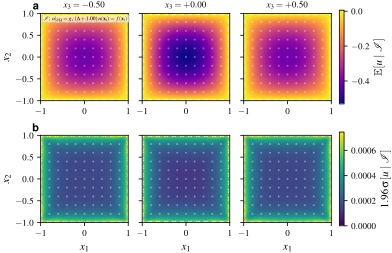

In [15]:
fig = plot_multiplane_slices(
    u_bc_pde, bvp,
    z_slices=(-0.50, 0.0, 0.50),
    resolution=50,
    X_pde=X_pde_flat,
    X_bc_list=X_bc_list,
)
fig.savefig('./helmholtz3d_posterior_1331pts.pdf', bbox_inches='tight')
plt.show()

In [16]:
def analytical_constant_source_3d(X, Y, Z, k_squared=1.0, M=51, N=51, P=51):
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    zeta = (Z + 1.0) / 2.0

    dtype = complex if np.iscomplexobj(k_squared) else float
    u = np.zeros_like(X, dtype=dtype)

    C = 2.0
    for m in range(1, M, 2):
        for n in range(1, N, 2):
            for p in range(1, P, 2):
                lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2 + (np.pi * p / 2) ** 2
                denom = -lam + k_squared
                f_coeff = C * (4.0 / np.pi) ** 3 / (m * n * p)
                u_coeff = f_coeff / denom
                u += u_coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta) * np.sin(np.pi * p * zeta)
    return u


nx, ny, nz = 21, 21, 21
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
z = np.linspace(-1, 1, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

pts = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)
u_pred = u_bc_pde.mean(pts).reshape(nx, ny, nz)

k2 = bvp.pde.k_squared
u_true = analytical_constant_source_3d(X, Y, Z, k_squared=k2, M=51, N=51, P=51)
u_true_real = np.real(u_true)

diff = u_true_real - u_pred

metrics = {
    "mse": float(np.mean(np.abs(diff) ** 2)),
    "rmse": float(np.sqrt(np.mean(np.abs(diff) ** 2))),
    "mae": float(np.mean(np.abs(diff))),
    "max_error": float(np.max(np.abs(diff))),
    "relative_l2": float(np.linalg.norm(diff) / np.linalg.norm(u_true_real)),
}

print("\nEvaluation Metrics (on 21×21×21 grid):")
print("-" * 40)
for name, value in metrics.items():
    print(f"  {name.upper():15s}: {value:.6e}")

print(f"\n  Solution range (GP):   [{np.min(u_pred):.4f}, {np.max(u_pred):.4f}]")


Evaluation Metrics (on 21×21×21 grid):
----------------------------------------
  MSE            : 2.646357e-06
  RMSE           : 1.626763e-03
  MAE            : 1.015283e-03
  MAX_ERROR      : 6.272538e-03
  RELATIVE_L2    : 7.593559e-03

  Solution range (GP):   [-0.5319, 0.0057]
